<a href="https://colab.research.google.com/github/balu-karthik/document-processing/blob/main/document-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pdf processing tool: pypdf


In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 7.3 MB/s eta 0:00:00


In [ ]:
import os

print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'sample_data']


Read the text of every page

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pypdf import PdfReader

reader = PdfReader("/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/test_file.pdf")

# Print the number of pages in the PDF
print(f"There are {len(reader.pages)} Pages")

# Get the first page (index 0)
page = reader.pages[10]
# Use extract_text() to get the text of the page
#print(page.extract_text())

#Go through every page and get the text
for i in range(len(reader.pages)):
  page = reader.pages[i]
  print(page.extract_text())


There are 32 Pages
Towards Reducing Continuous Emotion Annotation Effort During
Video Consumption: A Physiological Response Profiling Approach
SWARNALI BANIK, Department of Computer Science & Information Systems, BITS Pilani Goa, India 
SOUGATA SEN, APPCAIR, Department of Computer Science & Information Systems, BITS Pilani Goa, India 
SNEHANSHU SAHA, APPCAIR, Department of Computer Science & Information Systems, BITS Pilani 
Goa, and HappyMonk AI Labs, India
SURJYA GHOSH, APPCAIR, Department of Computer Science & Information Systems, BITS Pilani Goa, 
India
Fig. 1. Physiological response profile based opportunistic emotion annotation (PResUP) framework during video consumption 
scenario. (a) In traditional approach (absence of opportunistic annotation) during video watching, the user annotates 
continuously using an auxiliary device (e.g., joystick) and physiological signals also get recorded. (b) In the PResUP framework, 
the user is probed opportunistically for emotion annotation (se

Extract the image from a specific page


In [ ]:
save_folder="/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/"
import os
page = reader.pages[10]
print("Number of images found:", len(page.images))
for i, img in enumerate(page.images):
    print(f"Image {i}: {img.name}")
    file_path = os.path.join(save_folder, f"page10_image_{i}_{img.name}")
    with open(file_path, "wb") as fp:
        fp.write(img.data)

Number of images found: 2
Image 0: Im10.png
Image 1: Im9.png


Pdf processing tool: pdfplumber

In [ ]:
!pip install pdfplumber

In [ ]:
import pdfplumber
test_file="/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/test_file.pdf"
with pdfplumber.open(test_file) as pdf:
    # iterate over each page
    for page in pdf.pages:
        # extract text
        text = page.extract_text()
        print(text)

Towards Reducing Continuous Emotion Annotation Effort During
Video Consumption: A Physiological Response Profiling Approach
SWARNALIBANIK,
Department of Computer Science & Information Systems, BITS Pilani Goa, India
SOUGATASEN,
APPCAIR, Department of Computer Science & Information Systems, BITS Pilani Goa, India
SNEHANSHUSAHA,
APPCAIR, Department of Computer Science & Information Systems, BITS Pilani
Goa, and HappyMonk AI Labs, India
SURJYAGHOSH,
APPCAIR, Department of Computer Science & Information Systems, BITS Pilani Goa,
India
Fig. 1. Physiological response profile based opportunistic emotion annotation (PResUP) framework during video consumption
scenario. (a) In traditional approach (absence of opportunistic annotation) during video watching, the user annotates
continuously using an auxiliary device (e.g., joystick) and physiological signals also get recorded. (b) In the PResUP framework,
the user is probed opportunistically for emotion annotation (self-report). The user annotates

In each page it detects table. For some table it can only read the column and row name. For some it can read entire table.

In [ ]:
import pdfplumber
with pdfplumber.open(test_file) as pdf:
    # iterate over each page
    for page in pdf.pages:
        print(page.extract_tables())

[]
[]
[]
[]
[]
[]
[[['Videoid', 'Emotion', 'Valence', 'Arousal', 'Duration\n(insec.)'], ['1', 'amusing', 'med/high', 'med/high', '185'], ['2', 'amusing', 'med/high', 'med/high', '173'], ['3', 'boring', 'low', 'low', '119'], ['4', 'boring', 'low', 'low', '160'], ['5', 'relaxing', 'med/high', 'low', '145'], ['6', 'relaxing', 'med/high', 'low', '147'], ['7', 'scary', 'low', 'high', '197'], ['8', 'scary', 'low', 'high', '144']]]
[[['Totalnumberofsegments', '8608'], ['Totalnumberofopportunesegments', '1303'], ['Totalnumberofinopportunesegments', '7305'], ['Average(SD)numberofsegmentsperusers', '239±1.29'], ['Durationofeverysegment', '5Second'], ['Durationoftotalsensordataset', '11.96Hr.']]]
[]
[]
[[['Cluster#', 'ClusterCentroid\n(𝜇 𝑜𝑝𝑝 ,𝜎 𝑜𝑝𝑝 ,𝜇 𝑖𝑛𝑜𝑝𝑝 ,𝜎 𝑖𝑛𝑜𝑝𝑝)', 'AgeGroups\n(age_group:#M,#F)', '#ofMales', '#ofFemales'], ['1', '[7.690,2.805,6.053,1.666]', '(20-24:7M,5F),(25-29:4M,7F),(30-34:2F),(35-40:2M,2F)', '13', '16'], ['2', '[5.709,2.155,1.661,1.457]', '(20-24:1M,1F),(25-29:4M,1F)', '5

In [ ]:
!pip install --upgrade pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 50.6 MB/s eta 0:00:00


Extract Image

In [ ]:
import fitz
import os

# PDF location
pdf_path = "/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/test_file.pdf"

# Folder where extracted images will be saved
save_folder = "/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/"

# Open PDF
doc = fitz.open(pdf_path)

# Page 11 (index starts from 0)
page = doc[10]

# Get images from the page
image_list = page.get_images(full=True)

print("Number of images found:", len(image_list))

# Extract each image
for img_index, img_info in enumerate(image_list):

    xref = img_info[0]

    base_image = doc.extract_image(xref)

    image_bytes = base_image["image"]
    image_ext = base_image["ext"]

    # Give every image a unique name
    file_path = os.path.join(
        save_folder,
        f"page11_image_{img_index}.{image_ext}"
    )

    with open(file_path, "wb") as f:
        f.write(image_bytes)

    print("Saved:", file_path)

Number of images found: 2
Saved: /content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/page11_image_0.png
Saved: /content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/page11_image_1.png


pdf metadata & links in a page & render page as image

In [ ]:
# The import name for this library is fitz
import fitz

# Create a document object
doc = fitz.open('/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/test_file.pdf')  # or fitz.Document(filename)
# Folder where extracted images will be saved
save_folder = "/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/"

# Extract the number of pages (int)
print(doc.page_count)

# the metadata (dict) e.g., the author,...
print(doc.metadata)
print(f"title: {doc.metadata['title']}")
print(f"authors:{doc.metadata['author']}")

# Get the page by their index
page = doc.load_page(0)
 # or page = doc[0]

# read a Page
text = page.get_text()
#print(text)

# Render and save the page as an image
pix = page.get_pixmap()
file_path = os.path.join(
        save_folder,
        f"page_{page.number}.png"
    )
pix.save(file_path)
print("Saved:", file_path)

# get all links on a page
links = page.get_links()
print(links)

# # Render and save all the pages as images
# for i in range(doc.page_count):
#   page = doc.load_page(i)
#   pix = page.get_pixmap()
#   pix.save("page-%i.png" % page.number)

# # get the links on all pages
# for i in range(doc.page_count):
#   page = doc.load_page(i)
#   link = page.get_links()
#   print(link)

32
{'format': 'PDF 1.6', 'title': 'Towards Reducing Continuous Emotion Annotation Effort During Video Consumption: A Physiological Response Profiling Approach', 'author': 'Swarnali Banik', 'subject': '-  Human-centered computing  ->  Interactive systems and tools.Empirical studies in HCI.Contextual design.', 'keywords': 'Continuous emotion annotation, Physiological response, User Profile', 'creator': 'LaTeX with acmart 2024/05/27 v2.08 Typesetting articles for the Association for Computing Machinery and hyperref 2024-01-20 v7.01h Hypertext links for LaTeX', 'producer': 'pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) kpathsea version 6.4.0', 'creationDate': 'D:20240802083708Z', 'modDate': "D:20240806115251-04'00'", 'trapped': '', 'encryption': None}
title: Towards Reducing Continuous Emotion Annotation Effort During Video Consumption: A Physiological Response Profiling Approach
authors:Swarnali Banik
Saved: /content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/page_0.png
[{'kind

Text annotation

In [ ]:
import fitz

# Open PDF
pdf_path = "/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/test_file.pdf"
doc = fitz.open(pdf_path)

# Select page 11
page = doc[10]

# Search for text
text_instances = page.search_for("cluster")

# Add highlight annotation
for rect in text_instances:
    page.add_highlight_annot(rect)

# Save as a NEW annotated PDF
output_path = "/content/drive/MyDrive/PhdWork/Upgrad/pdf_extraction/annotated_test.pdf"
doc.save(output_path)

doc.close()

CSV reading, writting

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/sample_count.csv"
df=pd.read_csv(file_path)
df

,user_id,opp_count,nonopp_count
0,User1,122,369
1,User2,181,310
2,User3,148,343
3,User4,159,332
4,User5,126,365
5,User6,151,340
6,User8,178,313
7,User9,176,315
8,User10,184,307
9,User11,134,357


In [ ]:
import pandas as pd
df=pd.read_csv(file_path,skiprows=1)
df

,User1,122,369
0,User2,181,310
1,User3,148,343
2,User4,159,332
3,User5,126,365
4,User6,151,340
5,User8,178,313
6,User9,176,315
7,User10,184,307
8,User11,134,357
9,User12,121,370


In [ ]:
import pandas as pd
df=pd.read_csv(file_path,header=None,names=["ID_no","op","non-opp"])

df

,ID_no,op,non-opp
0,user_id,opp_count,nonopp_count
1,User1,122,369
2,User2,181,310
3,User3,148,343
4,User4,159,332
5,User5,126,365
6,User6,151,340
7,User8,178,313
8,User9,176,315
9,User10,184,307


In [ ]:
import pandas as pd
df=pd.read_csv(file_path,nrows=5)
df

,user_id,opp_count,nonopp_count
0,User1,122,369
1,User2,181,310
2,User3,148,343
3,User4,159,332
4,User5,126,365


In [ ]:
import pandas as pd
df=pd.read_csv(file_path,na_values=["Not available","N.A","NA"])
df


,user_id,opp_count,nonopp_count
0,User1,122.0,369.0
1,User2,181.0,310.0
2,User3,148.0,343.0
3,User4,159.0,332.0
4,User5,126.0,365.0
5,User6,151.0,340.0
6,User8,178.0,313.0
7,User9,176.0,315.0
8,User10,184.0,307.0
9,User11,134.0,357.0


Writting the csv file

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/sample2.csv"
df=pd.read_csv(file_path)
df

,tickers,eps,revenue,price,people
0,GOOGLE,27.82,87,845,larry page
1,WMT,4.61,484,65,n.a.
2,MSFT,-1,85,64,bill gates
3,RIL,n.a.,50,1023,mukesh ambani
4,TATA,5.6,-1,Not available,ratan tata


In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/sample2.csv"
df=pd.read_csv(file_path,na_values={"eps":["Not available","n.a."],"revenue":["Not available","n.a.",-1],
                                        "people":["Not available","n.a."]})
print(df)
write_file_path="/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/new.csv"
df.to_csv(write_file_path,index=False)

  tickers    eps  revenue          price         people
0  GOOGLE  27.82     87.0            845     larry page
1     WMT   4.61    484.0             65            NaN
2    MSFT  -1.00     85.0             64     bill gates
3     RIL    NaN     50.0           1023  mukesh ambani
4    TATA   5.60      NaN  Not available     ratan tata


In [ ]:
df.columns

Index(['tickers', 'eps', 'revenue', 'price', 'people'], dtype='object')

In [ ]:
write_file_path="/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/new2.csv"
df.to_csv(write_file_path,columns=["tickers","eps"])

In [ ]:
write_file_path="/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/new3.csv"
df.to_csv(write_file_path,header=False)

Read Excel file

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/sample2.xlsx"
#df=pd.read_excel("sample2.xlsx","Sheet1")
df=pd.read_excel(file_path)
df

,tickers,eps,revenue,price,people
0,GOOGLE,27.82,87,845,larry page
1,WMT,4.61,484,65,n.a.
2,MSFT,-1,85,64,bill gates
3,RIL,n.a.,50,1023,mukesh ambani
4,TATA,5.6,-1,Not available,ratan tata


In [ ]:
import pandas as pd

#df=pd.read_excel(file_path,"Sheet1")
def convert_people_cell(cell):
  if cell=="n.a.":
    return "sam walton"
  return cell
def convert_eps_cell(cell):
     if cell=="n.a.":
       return None
     return cell

df=pd.read_excel(file_path,"Sheet1",converters={
    'people':convert_people_cell,
    "eps":convert_eps_cell
})
df

,tickers,eps,revenue,price,people
0,GOOGLE,27.82,87,845,larry page
1,WMT,4.61,484,65,sam walton
2,MSFT,-1.00,85,64,bill gates
3,RIL,NaN,50,1023,mukesh ambani
4,TATA,5.60,-1,Not available,ratan tata


In [ ]:
file_path = "/content/drive/MyDrive/PhdWork/Upgrad/CSV_read_write/new.xlsx"
df.to_excel(file_path,sheet_name="stocks")

OCR

PIL (pillow)-> opne an image

OpenCV -> Change in image

PyTesseract-> OCR an image

In [ ]:
!sudo apt-get update
!sudo apt-get install -y tesseract-ocr
!pip install pytesseract

Get:1 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Get:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [3,015 kB]
Get:11 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1,268 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1,620 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Get:

In [ ]:
!pip install pillow
!pip install opencv-python


Open an image using pillow

In [ ]:
!pwd


/content


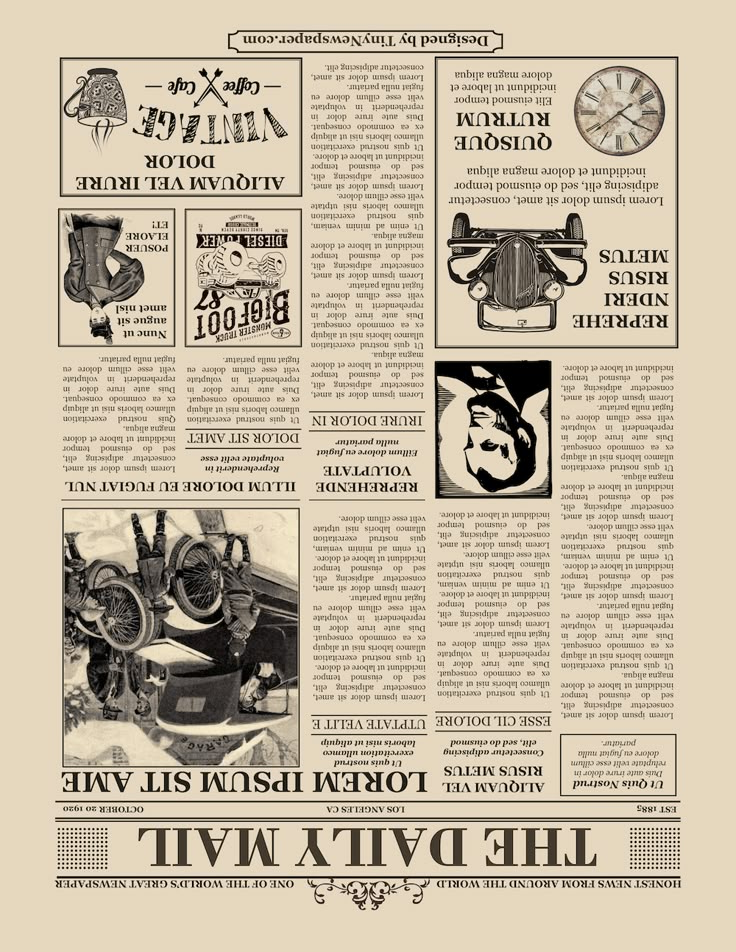

In [ ]:
import cv2
from PIL import Image
image_file="/content/drive/MyDrive/PhdWork/Upgrad/OCR/example.jpg"
image=Image.open(image_file)
# print(image)
# print(f'image size: {image.size}')
#image.show()
#display(image)
display(image.rotate(180))
file_save="/content/drive/MyDrive/PhdWork/Upgrad/OCR/"
image.save(file_save+"example_save.jpg")